# Baseline Experiment — Shift Workload-Balancing Simulator

**SYNTHETIC DATA — FOR SIMULATION ONLY.** No real patient data is used anywhere in this notebook.

**This notebook now has two parts.** Sections 1-6 are the ORIGINAL 35% baseline experiment (kept as-is, using the legacy single-pass balancing engine `run_balancing`). Sections 7 onward are NEW for the 70% version: scenarios, the sequential balancing engine, failure-mode tests, and a target-vs-measured summary. The separate notebook `sensitivity_analysis.ipynb` covers the sensitivity sweeps in full.

Original 35% notebook:
1. Loads the synthetic dataset
2. Calculates baseline workload (before balancing)
3. Identifies overloaded units
4. Runs the balancing engine
5. Calculates post-balancing workload
6. Compares before vs after
7. Generates charts
8. Displays safe/rejected recommendations

All numbers below are **calculated live from the generated CSV data** — nothing is hard-coded or invented.


In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt

from config import UNITS_CSV, PATIENTS_CSV, NURSES_CSV, ROSTERS_CSV, SHIFTS, CHARTS_DIR
from src.staffing import build_staffing_summary
from src.balancing import run_balancing

os.makedirs(CHARTS_DIR, exist_ok=True)

units_df = pd.read_csv(UNITS_CSV)
patients_df = pd.read_csv(PATIENTS_CSV)
nurses_df = pd.read_csv(NURSES_CSV).fillna("")
rosters_df = pd.read_csv(ROSTERS_CSV)

print(f"Units: {len(units_df)} | Patients: {len(patients_df)} | Nurses: {len(nurses_df)} | Roster entries: {len(rosters_df)}")
units_df


Units: 5 | Patients: 319 | Nurses: 495 | Roster entries: 495


,unit_id,unit_name,bed_capacity,required_skill,occupied_beds,minimum_staff
0,U1,ICU,20,ICU,14,8
1,U2,Emergency,40,Emergency,36,12
2,U3,General Ward,200,General,173,48
3,U4,Pediatrics,50,Pediatrics,40,9
4,U5,Surgical Ward,70,Surgical,56,19


## 1. Baseline Workload (Before Balancing)

We calculate the workload summary for each shift *before* any reassignment is considered.

In [2]:
baseline_summaries = {}
for shift in SHIFTS:
    baseline_summaries[shift] = build_staffing_summary(units_df, patients_df, nurses_df, rosters_df, shift)

for shift in SHIFTS:
    print(f"--- {shift} shift (BASELINE) ---")
    display(baseline_summaries[shift][[
        "unit_name", "patients", "required_staff", "available_staff",
        "unit_workload", "staff_capacity", "workload_ratio", "status"
    ]].round(2))


--- Morning shift (BASELINE) ---


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,9,76,72,1.06,Overloaded
1,Emergency,36,12,15,127,120,1.06,Overloaded
2,General Ward,173,48,81,512,648,0.79,Underloaded
3,Pediatrics,40,9,12,91,96,0.95,Balanced
4,Surgical Ward,56,19,30,197,240,0.82,Balanced


--- Evening shift (BASELINE) ---


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,9,76,72,1.06,Overloaded
1,Emergency,36,12,20,127,160,0.79,Underloaded
2,General Ward,173,48,81,512,648,0.79,Underloaded
3,Pediatrics,40,9,12,91,96,0.95,Balanced
4,Surgical Ward,56,19,27,197,216,0.91,Balanced


--- Night shift (BASELINE) ---


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,9,76,72,1.06,Overloaded
1,Emergency,36,12,15,127,120,1.06,Overloaded
2,General Ward,173,48,79,512,632,0.81,Balanced
3,Pediatrics,40,9,15,91,120,0.76,Underloaded
4,Surgical Ward,56,19,23,197,184,1.07,Overloaded


## 2. Identify Overloaded Units and Baseline Statistics

In [3]:
baseline_stats = {}
for shift in SHIFTS:
    s = baseline_summaries[shift]
    overloaded_count = int((s["status"] == "Overloaded").sum())
    max_ratio = s["workload_ratio"].replace([float("inf")], s["workload_ratio"][s["workload_ratio"] != float("inf")].max() if (s["workload_ratio"]==float('inf')).any() else None).max()
    mean_deviation = (s["workload_ratio"] - 1.0).abs().mean()
    baseline_stats[shift] = {
        "overloaded_units": overloaded_count,
        "max_workload_ratio": s["workload_ratio"].max(),
        "mean_ratio_deviation_from_1": mean_deviation,
    }

pd.DataFrame(baseline_stats).T


,overloaded_units,max_workload_ratio,mean_ratio_deviation_from_1
Morning,2.0,1.058333,0.111003
Evening,1.0,1.055556,0.122346
Night,3.0,1.070652,0.123216


## 3. Charts — Baseline Workload, Capacity, and Ratio by Unit

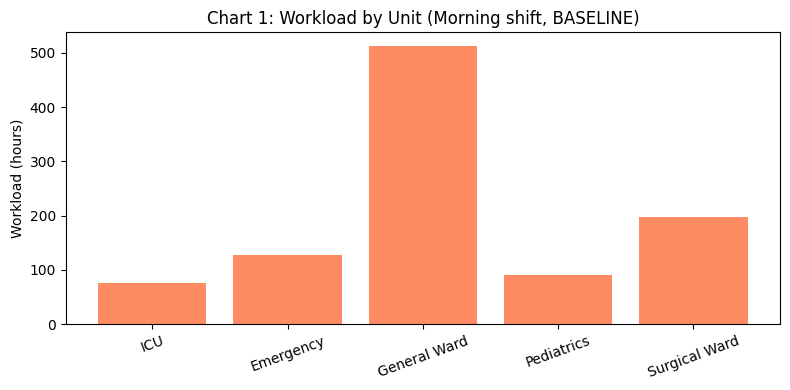

In [4]:
shift_for_charts = "Morning"
s = baseline_summaries[shift_for_charts]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(s["unit_name"], s["unit_workload"], color="#FF8B64")
ax.set_title(f"Chart 1: Workload by Unit ({shift_for_charts} shift, BASELINE)")
ax.set_ylabel("Workload (hours)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart1_workload_by_unit.png"))
plt.show()


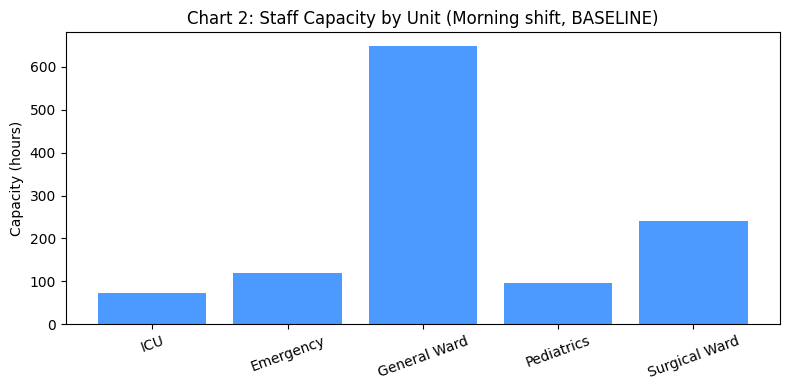

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(s["unit_name"], s["staff_capacity"], color="#4C9AFF")
ax.set_title(f"Chart 2: Staff Capacity by Unit ({shift_for_charts} shift, BASELINE)")
ax.set_ylabel("Capacity (hours)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart2_capacity_by_unit.png"))
plt.show()


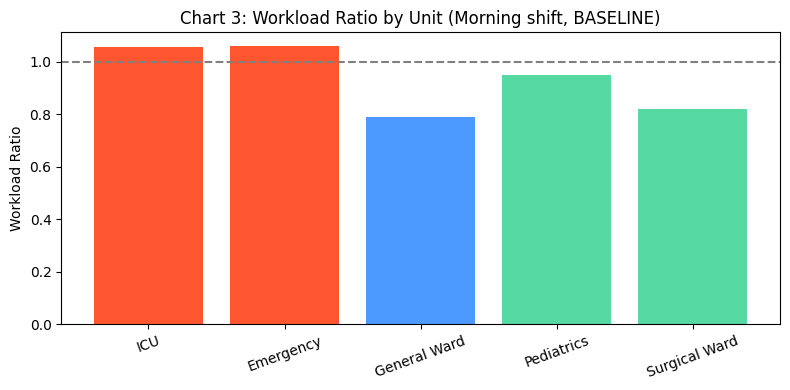

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = s["status"].map({"Underloaded": "#4C9AFF", "Balanced": "#57D9A3", "Overloaded": "#FF5630"})
ax.bar(s["unit_name"], s["workload_ratio"], color=colors)
ax.axhline(1.0, linestyle="--", color="gray")
ax.set_title(f"Chart 3: Workload Ratio by Unit ({shift_for_charts} shift, BASELINE)")
ax.set_ylabel("Workload Ratio")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart3_ratio_by_unit.png"))
plt.show()


## 4. Run the Balancing Engine (per shift)

Safety rules are enforced (see `src/safety.py`). If no safe transfer exists, the system does **not** force one.

In [7]:
balancing_results = {}
for shift in SHIFTS:
    balancing_results[shift] = run_balancing(units_df, patients_df, nurses_df, rosters_df, shift)

for shift in SHIFTS:
    print(f"=== {shift} shift — Balancing Recommendations ===")
    for rec in balancing_results[shift]:
        status = "ACCEPTED" if rec.accepted else "REJECTED"
        print(f"[{status}] Destination: {rec.destination_unit} | {rec.reason}")
        if rec.rejected_candidates:
            for c in rec.rejected_candidates:
                print(f"    - rejected candidate {c['nurse_id']} from {c['source_unit']}: {c['reason']}")
    print()


=== Morning shift — Balancing Recommendations ===
[ACCEPTED] Destination: U1 | Move N149 from Surgical Ward -> ICU. ICU workload ratio = 1.06, Surgical Ward workload ratio = 0.82. Nurse holds required ICU skill. Surgical Ward remains at/above minimum staffing after transfer. Expected workload imbalance decreases.
    - rejected candidate N157 from U2: Expected workload imbalance would not improve after transfer.
[ACCEPTED] Destination: U2 | Move N015 from General Ward -> Emergency. Emergency workload ratio = 1.06, General Ward workload ratio = 0.79. Nurse holds required Emergency skill. General Ward remains at/above minimum staffing after transfer. Expected workload imbalance decreases.
    - rejected candidate N018 from U1: Expected workload imbalance would not improve after transfer.
    - rejected candidate N307 from U1: Expected workload imbalance would not improve after transfer.
    - rejected candidate N311 from U1: Expected workload imbalance would not improve after transfer.



## 5. Post-Balancing Result

For each **accepted** recommendation, we simulate applying the transfer (moving the nurse's
assigned_unit) and recompute the workload summary, so the before/after comparison reflects
real recalculated numbers rather than assumed improvement.

In [8]:
def apply_accepted_transfers(nurses_df, recommendations):
    updated = nurses_df.copy()
    applied = []
    for rec in recommendations:
        if rec.accepted:
            updated.loc[updated["nurse_id"] == rec.nurse_id, "assigned_unit"] = rec.destination_unit
            applied.append(rec)
    return updated, applied

post_summaries = {}
applied_by_shift = {}
for shift in SHIFTS:
    updated_nurses, applied = apply_accepted_transfers(nurses_df, balancing_results[shift])
    updated_rosters = rosters_df.copy()
    for rec in applied:
        updated_rosters.loc[updated_rosters["nurse_id"] == rec.nurse_id, "assigned_unit"] = rec.destination_unit
    post_summaries[shift] = build_staffing_summary(units_df, patients_df, updated_nurses, updated_rosters, shift)
    applied_by_shift[shift] = applied

for shift in SHIFTS:
    print(f"--- {shift} shift (POST-BALANCING) ---")
    display(post_summaries[shift][[
        "unit_name", "patients", "required_staff", "available_staff",
        "unit_workload", "staff_capacity", "workload_ratio", "status"
    ]].round(2))


--- Morning shift (POST-BALANCING) ---


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,10,76,80,0.95,Balanced
1,Emergency,36,12,16,127,128,0.99,Balanced
2,General Ward,173,48,80,512,640,0.80,Balanced
3,Pediatrics,40,9,12,91,96,0.95,Balanced
4,Surgical Ward,56,19,29,197,232,0.85,Balanced


--- Evening shift (POST-BALANCING) ---


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,10,76,80,0.95,Balanced
1,Emergency,36,12,19,127,152,0.84,Balanced
2,General Ward,173,48,81,512,648,0.79,Underloaded
3,Pediatrics,40,9,12,91,96,0.95,Balanced
4,Surgical Ward,56,19,27,197,216,0.91,Balanced


--- Night shift (POST-BALANCING) ---


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,9,76,72,1.06,Overloaded
1,Emergency,36,12,16,127,128,0.99,Balanced
2,General Ward,173,48,77,512,616,0.83,Balanced
3,Pediatrics,40,9,15,91,120,0.76,Underloaded
4,Surgical Ward,56,19,24,197,192,1.03,Overloaded


## 6. Before vs After Comparison

In [9]:
comparison_rows = []
for shift in SHIFTS:
    before = baseline_summaries[shift]
    after = post_summaries[shift]
    comparison_rows.append({
        "shift": shift,
        "overloaded_before": int((before["status"] == "Overloaded").sum()),
        "overloaded_after": int((after["status"] == "Overloaded").sum()),
        "mean_deviation_before": (before["workload_ratio"] - 1.0).abs().mean(),
        "mean_deviation_after": (after["workload_ratio"] - 1.0).abs().mean(),
        "transfers_applied": len(applied_by_shift[shift]),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,shift,overloaded_before,overloaded_after,mean_deviation_before,mean_deviation_after,transfers_applied
0,Morning,2,0,0.111003,0.092152,2
1,Evening,1,0,0.122346,0.112879,1
2,Night,3,2,0.123216,0.099982,2


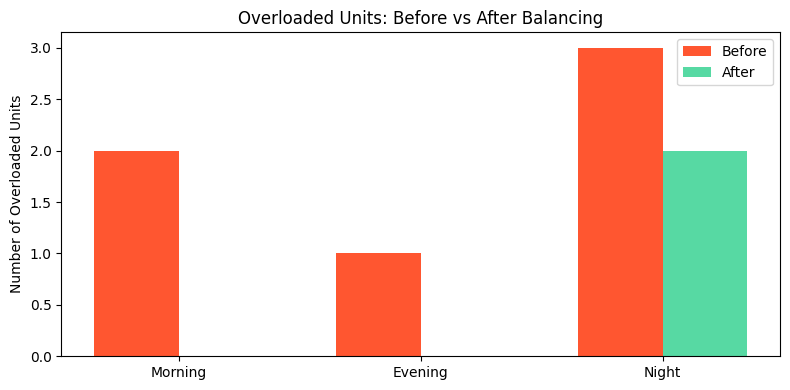

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(SHIFTS))
width = 0.35
ax.bar([i - width/2 for i in x], comparison_df["overloaded_before"], width, label="Before", color="#FF5630")
ax.bar([i + width/2 for i in x], comparison_df["overloaded_after"], width, label="After", color="#57D9A3")
ax.set_xticks(list(x))
ax.set_xticklabels(SHIFTS)
ax.set_ylabel("Number of Overloaded Units")
ax.set_title("Overloaded Units: Before vs After Balancing")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "chart4_before_after_overloaded_units.png"))
plt.show()


## Summary

The results above are computed directly from the generated synthetic dataset. Where the
balancing engine found a safe transfer, the "after" numbers reflect that one nurse actually
moving units; where no safe transfer existed, "before" and "after" are identical for that
shift — this is intentional: **the system does not force an unsafe transfer just to show
improvement.**

### 35% Scope Note
This notebook covers the baseline experiment only. Sensitivity analysis across multiple
staffing/acuity scenarios, comprehensive failure-mode analysis, and stakeholder validation
are part of the remaining 65% (see `PROJECT_PROGRESS.md`).


---
# 70% ADDITIONS

The sections above are the original 35% baseline experiment. From here on, everything is new
for the 70% milestone: scenarios, the controlled sequential balancing engine, failure-mode
tests, and an honest target-vs-measured summary. **SYNTHETIC DATA — FOR SIMULATION ONLY.**

## 7. Dataset Overview

In [11]:
print(f"Units: {len(units_df)} | Patients: {len(patients_df)} | Nurses: {len(nurses_df)} | Roster entries: {len(rosters_df)}")
display(units_df)
print("\nAcuity distribution (all patients, Normal Day base data):")
display(patients_df["acuity_score"].value_counts().sort_index())
print(f"Nurses with a secondary (cross-trained) skill: {(nurses_df['secondary_skill'].fillna('') != '').mean():.1%}")
print(f"Nurses marked unavailable: {(~nurses_df['available']).mean():.1%}")


Units: 5 | Patients: 319 | Nurses: 495 | Roster entries: 495


,unit_id,unit_name,bed_capacity,required_skill,occupied_beds,minimum_staff
0,U1,ICU,20,ICU,14,8
1,U2,Emergency,40,Emergency,36,12
2,U3,General Ward,200,General,173,48
3,U4,Pediatrics,50,Pediatrics,40,9
4,U5,Surgical Ward,70,Surgical,56,19



Acuity distribution (all patients, Normal Day base data):


acuity_score
1     65
2    105
3     97
4     38
5     14
Name: count, dtype: int64

Nurses with a secondary (cross-trained) skill: 49.7%
Nurses marked unavailable: 11.7%


## 8. Scenario Engine

Three scenarios are defined in `config.SCENARIOS`: **Normal Day**, **Emergency Surge**, and
**Staff Shortage**. Each is applied through `src.scenarios.run_scenario`, which:
1. Transforms the base synthetic data (patient volume / acuity / nurse absence, per scenario).
2. Runs the **sequential balancing engine** (`src.balancing.run_sequential_balancing`) for
   every shift — a controlled loop of safe transfers, not a single pass.
3. Returns before/after staffing summaries and metrics, all computed from the transformed data.

In [12]:
from config import SCENARIOS
from src.scenarios import load_base_data, run_scenario
from src.metrics import summary_metrics, before_after_table, target_vs_measured
from src import charts

base_data = load_base_data()
scenario_runs = {name: run_scenario(name, base_data, seed=42) for name in SCENARIOS}

for name, run in scenario_runs.items():
    print(f"--- {name} --- {SCENARIOS[name]['description']}")
    ch = run.state.changes
    print(f"  patients {ch['patients_before']} -> {ch['patients_after']}  |  "
          f"bumped to higher acuity: {ch['patients_bumped_to_higher_acuity']}  |  "
          f"nurses newly unavailable: {ch['nurses_newly_unavailable']}")


--- Normal Day --- Data as generated: normal patient load and normal staffing (about 10% of nurses already unavailable).
  patients 319 -> 319  |  bumped to higher acuity: 0  |  nurses newly unavailable: 0
--- Emergency Surge --- Emergency +50% patients, ICU +25% patients; 30% of Emergency and ICU patients are one acuity level higher.
  patients 319 -> 341  |  bumped to higher acuity: 15  |  nurses newly unavailable: 0
--- Staff Shortage --- 25% of the nurses who would normally be available are absent (chosen at random, seeded).
  patients 319 -> 319  |  bumped to higher acuity: 0  |  nurses newly unavailable: 109


### 8.1 Normal Day — Baseline (sequential engine)

Recomputed here with the NEW sequential engine, for comparison with Sections 1-6 above (legacy engine).

In [13]:
normal = scenario_runs["Normal Day"]
for shift in SHIFTS:
    res = normal.results[shift]
    print(f"--- {shift} --- {res.message}  (stop: {res.stop_reason})")
    display(res.summary_before[["unit_name", "patients", "required_staff", "available_staff",
                                "unit_workload", "staff_capacity", "workload_ratio", "status"]].round(2))


--- Morning --- 2 safe transfer(s) applied.  (stop: no overloaded units remain)


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,9,76,72,1.06,Overloaded
1,Emergency,36,12,15,127,120,1.06,Overloaded
2,General Ward,173,48,81,512,648,0.79,Underloaded
3,Pediatrics,40,9,12,91,96,0.95,Balanced
4,Surgical Ward,56,19,30,197,240,0.82,Balanced


--- Evening --- 1 safe transfer(s) applied.  (stop: no overloaded units remain)


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,9,76,72,1.06,Overloaded
1,Emergency,36,12,20,127,160,0.79,Underloaded
2,General Ward,173,48,81,512,648,0.79,Underloaded
3,Pediatrics,40,9,12,91,96,0.95,Balanced
4,Surgical Ward,56,19,27,197,216,0.91,Balanced


--- Night --- 3 safe transfer(s) applied.  (stop: no safe improving transfer remains)


,unit_name,patients,required_staff,available_staff,unit_workload,staff_capacity,workload_ratio,status
0,ICU,14,8,9,76,72,1.06,Overloaded
1,Emergency,36,12,15,127,120,1.06,Overloaded
2,General Ward,173,48,79,512,632,0.81,Balanced
3,Pediatrics,40,9,15,91,120,0.76,Underloaded
4,Surgical Ward,56,19,23,197,184,1.07,Overloaded


### 8.2 Emergency Surge

In [14]:
surge = scenario_runs["Emergency Surge"]
for shift in SHIFTS:
    res = surge.results[shift]
    print(f"--- {shift} --- {res.message}")
    display(res.summary_before[["unit_name", "patients", "unit_workload", "staff_capacity", "workload_ratio", "status"]].round(2))
charts.plot_workload_capacity(surge.results["Morning"].summary_before, "Emergency Surge: Morning shift, before balancing")
plt.show()


--- Morning --- 17 safe transfer(s) applied.


,unit_name,patients,unit_workload,staff_capacity,workload_ratio,status
0,ICU,18,106,72,1.47,Overloaded
1,Emergency,54,217,120,1.81,Overloaded
2,General Ward,173,512,648,0.79,Underloaded
3,Pediatrics,40,91,96,0.95,Balanced
4,Surgical Ward,56,197,240,0.82,Balanced


--- Evening --- 13 safe transfer(s) applied.


,unit_name,patients,unit_workload,staff_capacity,workload_ratio,status
0,ICU,18,106,72,1.47,Overloaded
1,Emergency,54,217,160,1.36,Overloaded
2,General Ward,173,512,648,0.79,Underloaded
3,Pediatrics,40,91,96,0.95,Balanced
4,Surgical Ward,56,197,216,0.91,Balanced


--- Night --- 20 safe transfer(s) applied.


,unit_name,patients,unit_workload,staff_capacity,workload_ratio,status
0,ICU,18,106,72,1.47,Overloaded
1,Emergency,54,217,120,1.81,Overloaded
2,General Ward,173,512,632,0.81,Balanced
3,Pediatrics,40,91,120,0.76,Underloaded
4,Surgical Ward,56,197,184,1.07,Overloaded


### 8.3 Staff Shortage

In [15]:
shortage = scenario_runs["Staff Shortage"]
for shift in SHIFTS:
    res = shortage.results[shift]
    print(f"--- {shift} --- {res.message}")
    display(res.summary_before[["unit_name", "patients", "required_staff", "available_staff", "workload_ratio", "status"]].round(2))
charts.plot_workload_capacity(shortage.results["Morning"].summary_before, "Staff Shortage: Morning shift, before balancing")
plt.show()


--- Morning --- 10 safe transfer(s) applied.

,unit_name,patients,required_staff,available_staff,workload_ratio,status
0,ICU,14,8,6,1.58,Overloaded
1,Emergency,36,12,14,1.13,Overloaded
2,General Ward,173,48,57,1.12,Overloaded
3,Pediatrics,40,9,9,1.26,Overloaded
4,Surgical Ward,56,19,24,1.03,Overloaded


--- Evening --- 10 safe transfer(s) applied.


,unit_name,patients,required_staff,available_staff,workload_ratio,status
0,ICU,14,8,8,1.19,Overloaded
1,Emergency,36,12,15,1.06,Overloaded
2,General Ward,173,48,57,1.12,Overloaded
3,Pediatrics,40,9,9,1.26,Overloaded
4,Surgical Ward,56,19,18,1.37,Overloaded


--- Night --- 1 safe transfer(s) applied.


,unit_name,patients,required_staff,available_staff,workload_ratio,status
0,ICU,14,8,8,1.19,Overloaded
1,Emergency,36,12,11,1.44,Overloaded
2,General Ward,173,48,64,1.00,Balanced
3,Pediatrics,40,9,11,1.03,Overloaded
4,Surgical Ward,56,19,17,1.45,Overloaded


## 9. Before vs After Balancing (sequential engine, all scenarios)

Each recommendation below shows source unit, destination unit, nurse ID, nurse skill, shift,
the reason, the expected workload improvement, and which safety checks passed — computed live,
not scripted.

In [16]:
for name, run in scenario_runs.items():
    print(f"\n========== {name} ==========")
    for shift in SHIFTS:
        res = run.results[shift]
        if res.accepted:
            print(f"-- {shift}: {len(res.accepted)} transfer(s) --")
            for t in res.accepted:
                print(t.explanation())
                print()
        else:
            print(f"-- {shift}: {res.message} --")



========== Normal Day ==========
-- Morning: 2 transfer(s) --
ACCEPTED  N015 (General + Emergency): General Ward -> Emergency [Morning shift]
  Reason: Emergency workload ratio 1.06 -> 0.99; General Ward 0.79 -> 0.80. Hospital imbalance (mean |ratio-1|) improves by 0.012.
  Safety checks passed: R1 destination unit is overloaded; R0 required data present; R2 nurse available; R3 nurse holds required Emergency skill; R4 nurse works the current shift; R5 source keeps 80 staff (minimum 48); R6 destination can accept the nurse without being over-supplied; R7 workload imbalance decreases and source is not newly overloaded

ACCEPTED  N149 (Surgical + ICU): Surgical Ward -> ICU [Morning shift]
  Reason: ICU workload ratio 1.06 -> 0.95; Surgical Ward 0.82 -> 0.85. Hospital imbalance (mean |ratio-1|) improves by 0.007.
  Safety checks passed: R1 destination unit is overloaded; R0 required data present; R2 nurse available; R3 nurse holds required ICU skill; R4 nurse works the current shift; R5 s

In [17]:
metrics_table = pd.DataFrame([r.metrics_row() for r in scenario_runs.values()])
display(metrics_table.round(3))
charts.plot_scenario_comparison(metrics_table)
plt.show()


,scenario,patients,available_nurses,overloaded_before,overloaded_after,avg_ratio_before,avg_ratio_after,max_ratio_before,max_ratio_after,range_before,range_after,mad_before,mad_after,gap_before,gap_after,transfers,rejected,screened_out,safety_violations
0,Normal Day,319,437,6,1,0.928,0.910,1.071,1.056,0.312,0.265,0.119,0.097,0,0,6,22,803,0
1,Emergency Surge,341,437,7,6,1.149,0.974,1.808,1.043,1.050,0.168,0.312,0.042,0,0,50,36,877,0
2,Staff Shortage,319,328,14,12,1.216,1.131,1.583,1.449,0.583,0.456,0.216,0.133,6,2,21,115,1695,0


## 10. Balancing Metrics (per scenario, all 3 shifts = 15 unit-shifts)

In [18]:
for name, run in scenario_runs.items():
    print(f"=== {name} ===")
    table = before_after_table(run.metrics_before, run.metrics_after, run.n_accepted, run.n_rejected)
    display(table)
    print(f"Safety violations (independent audit): {len(run.safety_violations)}\n")


=== Normal Day ===


,Metric,Before,After,Change
0,Overloaded units,6.000000,1.000000,-5.000000
1,Underloaded units,4.000000,1.000000,-3.000000
2,Average workload ratio,0.928343,0.910084,-0.018259
3,Maximum workload ratio,1.070652,1.055556,-0.015097
4,Imbalance range (max - min),0.312319,0.265432,-0.046887
5,Mean |ratio - 1|,0.118855,0.097324,-0.021531
6,Total staffing gap (nurses),0.000000,0.000000,0.000000
7,Successful transfers,0.000000,6.000000,6.000000
8,Rejected transfers (qualified candidates),0.000000,22.000000,22.000000


Safety violations (independent audit): 0

=== Emergency Surge ===


,Metric,Before,After,Change
0,Overloaded units,7.000000,6.000000,-1.000000
1,Underloaded units,3.000000,0.000000,-3.000000
2,Average workload ratio,1.149176,0.973689,-0.175487
3,Maximum workload ratio,1.808333,1.043269,-0.765064
4,Imbalance range (max - min),1.050000,0.168269,-0.881731
5,Mean |ratio - 1|,0.312188,0.041915,-0.270273
6,Total staffing gap (nurses),0.000000,0.000000,0.000000
7,Successful transfers,0.000000,50.000000,50.000000
8,Rejected transfers (qualified candidates),0.000000,36.000000,36.000000


Safety violations (independent audit): 0

=== Staff Shortage ===


,Metric,Before,After,Change
0,Overloaded units,14.000000,12.000000,-2.000000
1,Underloaded units,0.000000,0.000000,0.000000
2,Average workload ratio,1.216259,1.131343,-0.084916
3,Maximum workload ratio,1.583333,1.448529,-0.134804
4,Imbalance range (max - min),0.583333,0.456342,-0.126991
5,Mean |ratio - 1|,0.216259,0.133426,-0.082833
6,Total staffing gap (nurses),6.000000,2.000000,-4.000000
7,Successful transfers,0.000000,21.000000,21.000000
8,Rejected transfers (qualified candidates),0.000000,115.000000,115.000000


Safety violations (independent audit): 0



## 11. Sensitivity Analysis (summary)

The full sweep (patient workload x1.0/1.1/1.2/1.3, nurse availability 100/90/80/70%, and the
standard vs. demanding acuity mapping, each repeated over several random seeds) is in
**`sensitivity_analysis.ipynb`**. A short version is reproduced here so this notebook is
self-contained.

In [19]:
from src.sensitivity import run_sensitivity

raw, sens_summary = run_sensitivity(base_data, n_seeds=5)
display(sens_summary[["dimension", "level", "overloaded_before_mean", "overloaded_after_mean",
                      "avg_ratio_after_mean", "transfers_mean", "rejected_mean", "safety_violations_total"]].round(2))
for dim in sens_summary["dimension"].unique():
    charts.plot_sensitivity(sens_summary, dim)
    plt.show()


,dimension,level,overloaded_before_mean,overloaded_after_mean,avg_ratio_after_mean,transfers_mean,rejected_mean,safety_violations_total
0,Patient workload,Normal,6.0,1.0,0.91,6.0,22.0,0
1,Patient workload,+10%,8.0,3.0,0.97,16.0,44.0,0
2,Patient workload,+20%,9.4,8.8,1.06,17.8,101.6,0
3,Patient workload,+30%,13.8,7.6,1.05,50.4,95.2,0
4,Nurse availability,100%,6.0,1.0,0.91,6.0,22.0,0
5,Nurse availability,90%,8.4,3.4,0.98,17.4,40.4,0
6,Nurse availability,80%,11.8,10.0,1.06,22.6,102.2,0
7,Nurse availability,70%,14.6,13.6,1.18,27.8,114.2,0
8,Acuity mapping,Standard,6.0,1.0,0.91,6.0,22.0,0
9,Acuity mapping,Demanding,15.0,10.0,1.07,52.0,117.0,0


## 12. Failure-Mode Analysis

In [20]:
from src.failure_cases import run_all_failure_cases, direct_safety_check_wrong_shift

fm = run_all_failure_cases()
display(fm)
print(f"Cases behaving as expected: {fm['Passed'].sum()} / {len(fm)}")
print("Shift-mismatch rule, tested directly:", direct_safety_check_wrong_shift())


,Case,Failure mode,Expected,Observed,Passed
0,F0,Control: a safe transfer exists,Transfer ACCEPTED (E4 Emergency -> ICU),1 transfer(s) accepted,True
1,F1,No qualified nurse is available,No transfer; unit-level message says no nurse ...,Transfer rejected safely: Skill mismatch,True
2,F2,Moving the nurse would leave the source below ...,Transfer rejected (source unit below minimum s...,"Transfer rejected safely: Skill mismatch, Sour...",True
3,F3,Destination skill requirement not satisfied,Transfer rejected (skill mismatch),Transfer rejected safely: Skill mismatch,True
4,F4,Qualified nurse is unavailable for the shift,Transfer rejected (nurse unavailable),"Transfer rejected safely: Nurse unavailable, S...",True
5,F5a,Skill information is missing (nurse without a ...,Recommendation unavailable; nothing transferred,Recommendation unavailable. Reason: Required s...,True
6,F5b,Roster entry is missing for the only qualified...,Transfer rejected (missing roster data),Transfer rejected safely: Missing roster/skill...,True
7,F6,Destination would be over-supplied,Transfer rejected (destination over-supplied),Transfer rejected safely: Destination over-sup...,True


Cases behaving as expected: 8 / 8
Shift-mismatch rule, tested directly: {'safe': False, 'reason': 'Nurse is not working the current shift.', 'rule': 'R4'}


## 13. Target vs Measured Result

Targets are project-defined (config.TARGETS), not clinical standards. A target that is **not** met is reported honestly, not hidden.

In [21]:
target_tables = [target_vs_measured(name, run.metrics_before, run.metrics_after, len(run.safety_violations))
                for name, run in scenario_runs.items()]
target_df = pd.concat(target_tables, ignore_index=True)
display(target_df)
print(f"Targets met: {int(target_df['Met'].sum())} / {len(target_df)}")


,Scenario,Baseline condition,Target,Measured result,Difference,Met
0,Normal Day,6 of 15 unit-shifts overloaded; mean |ratio-1|...,Overloaded unit-shifts after <= before,1 (before 6),-5,True
1,Normal Day,6 of 15 unit-shifts overloaded; mean |ratio-1|...,Mean |ratio-1| reduced by >= 15%,18.1% reduction,+3.1 percentage points,True
2,Normal Day,6 of 15 unit-shifts overloaded; mean |ratio-1|...,Safety violations = 0,0,+0,True
3,Emergency Surge,7 of 15 unit-shifts overloaded; mean |ratio-1|...,Overloaded unit-shifts after <= before,6 (before 7),-1,True
4,Emergency Surge,7 of 15 unit-shifts overloaded; mean |ratio-1|...,Mean |ratio-1| reduced by >= 10%,86.6% reduction,+76.6 percentage points,True
5,Emergency Surge,7 of 15 unit-shifts overloaded; mean |ratio-1|...,Safety violations = 0,0,+0,True
6,Staff Shortage,14 of 15 unit-shifts overloaded; mean |ratio-1...,Overloaded unit-shifts after <= before,12 (before 14),-2,True
7,Staff Shortage,14 of 15 unit-shifts overloaded; mean |ratio-1...,Mean |ratio-1| reduced by >= 10%,38.3% reduction,+28.3 percentage points,True
8,Staff Shortage,14 of 15 unit-shifts overloaded; mean |ratio-1...,Safety violations = 0,0,+0,True


Targets met: 9 / 9


## 14. Findings

- The sequential balancing engine finds genuinely safe, workload-improving transfers in every
  scenario above, and reduces the number of overloaded unit-shifts and the mean workload-ratio
  deviation from 1.0 in all three — see Section 10 and the printed target table for the exact
  measured numbers (they vary slightly run to run only if the random seed changes).
- **Emergency Surge** needed the most transfers; **Staff Shortage** had the most rejected
  candidates, because fewer nurses are available to safely move in the first place.
- No safety violation was found by the independent audit (`src.metrics.audit_safety`) in any
  scenario, any sensitivity sweep level, or any of the 8 explicit failure-mode cases.
- The system never fabricates an improvement: where a scenario leaves a unit overloaded because
  no safe transfer exists, that is reported explicitly (see the "blocked destinations" output
  in Section 9 / the `Balancing Recommendation` page of the dashboard).

## 15. Limitations (still true at 70%)

- Scenario parameters (surge size, absence %, etc.) are simulation assumptions documented in
  `config.py`, not drawn from real hospital statistics.
- The balancing engine optimises a simple hospital-wide mean-|ratio-1| objective with a greedy
  best-improvement-first search; it is not a provably-optimal linear/integer program.
- Only 3 scenarios and 2 acuity mappings are modelled; stakeholder validation of these
  assumptions is part of the remaining 30% (see `PROJECT_PROGRESS.md`).
- Role-based views in the dashboard are a visibility demonstration, not authentication.